# 🦟 Notebook 01 — Exploratory Data Analysis
**SINDy with Environmental Covariates on DengAI Data**

---
### Objectives
1. Load & merge features + labels
2. Understand data shape, types, missing values
3. Visualise dengue case time series & seasonal patterns
4. Explore environmental feature distributions
5. Correlation analysis (features ↔ cases)
6. Identify key epidemic events
---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.data_utils import (
    load_raw_data, split_by_city, missing_summary,
    NDVI_COLS, TEMP_COLS, PRECIP_COLS, HUMIDITY_COLS, ENV_FEATURE_COLS
)
from src.plot_utils import set_project_style, PALETTE, city_label, city_color, save_fig

set_project_style()
pd.set_option('display.max_columns', 30)
print('✅ All imports ready')

✅ All imports ready


## 1 · Load & Merge Data

In [2]:
df = load_raw_data()
print(f'Combined shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Combined shape: (1456, 25)
Columns: ['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm', 'total_cases']


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   city                                   1456 non-null   object        
 1   year                                   1456 non-null   int64         
 2   weekofyear                             1456 non-null   int64         
 3   week_start_date                        1456 non-null   datetime64[ns]
 4   ndvi_ne                                1262 non-null   float64       
 5   ndvi_nw                                1404 non-null   float64       
 6   ndvi_se                                1434 non-null   float64       
 7   ndvi_sw                                1434 non-null   float64       
 8   precipitation_amt_mm                   1443 non-null   float64       
 9   reanalysis_air_temp_k                  1446 non-null   float64 

In [4]:
df.describe().T.style.background_gradient(cmap='YlOrRd', subset=['mean','std'])

TypeError: float() argument must be a string or a real number, not 'Timestamp'

## 2 · City-wise Split

In [5]:
df_sj, df_iq = split_by_city(df)

print(f'San Juan  : {len(df_sj)} weeks  |  {df_sj["year"].min()}–{df_sj["year"].max()}')
print(f'Iquitos   : {len(df_iq)} weeks  |  {df_iq["year"].min()}–{df_iq["year"].max()}')
print(f'\nSan Juan avg cases/week : {df_sj["total_cases"].mean():.1f}')
print(f'Iquitos  avg cases/week : {df_iq["total_cases"].mean():.1f}')
print(f'San Juan peak cases     : {df_sj["total_cases"].max()}')
print(f'Iquitos  peak cases     : {df_iq["total_cases"].max()}')

San Juan  : 936 weeks  |  1990–2008
Iquitos   : 520 weeks  |  2000–2010

San Juan avg cases/week : 34.2
Iquitos  avg cases/week : 7.6
San Juan peak cases     : 461
Iquitos  peak cases     : 116


## 3 · Missing Value Analysis

In [6]:
print('=== Overall Missing Values ===')
display(missing_summary(df))

print('\n=== San Juan ===')
display(missing_summary(df_sj))

print('\n=== Iquitos ===')
display(missing_summary(df_iq))

=== Overall Missing Values ===


,n_missing,pct_missing
ndvi_ne,194,13.32
ndvi_nw,52,3.57
station_avg_temp_c,43,2.95
station_diur_temp_rng_c,43,2.95
ndvi_sw,22,1.51
ndvi_se,22,1.51
station_precip_mm,22,1.51
station_max_temp_c,20,1.37
station_min_temp_c,14,0.96
precipitation_amt_mm,13,0.89



=== San Juan ===


,n_missing,pct_missing
ndvi_ne,191,20.41
ndvi_nw,49,5.24
ndvi_se,19,2.03
ndvi_sw,19,2.03
precipitation_amt_mm,9,0.96
reanalysis_sat_precip_amt_mm,9,0.96
reanalysis_avg_temp_k,6,0.64
reanalysis_air_temp_k,6,0.64
reanalysis_max_air_temp_k,6,0.64
reanalysis_min_air_temp_k,6,0.64



=== Iquitos ===


,n_missing,pct_missing
station_avg_temp_c,37,7.12
station_diur_temp_rng_c,37,7.12
station_precip_mm,16,3.08
station_max_temp_c,14,2.69
station_min_temp_c,8,1.54
reanalysis_precip_amt_kg_per_m2,4,0.77
reanalysis_min_air_temp_k,4,0.77
reanalysis_max_air_temp_k,4,0.77
reanalysis_relative_humidity_percent,4,0.77
precipitation_amt_mm,4,0.77


  ✅ Saved → figures\01_missing_heatmap.png


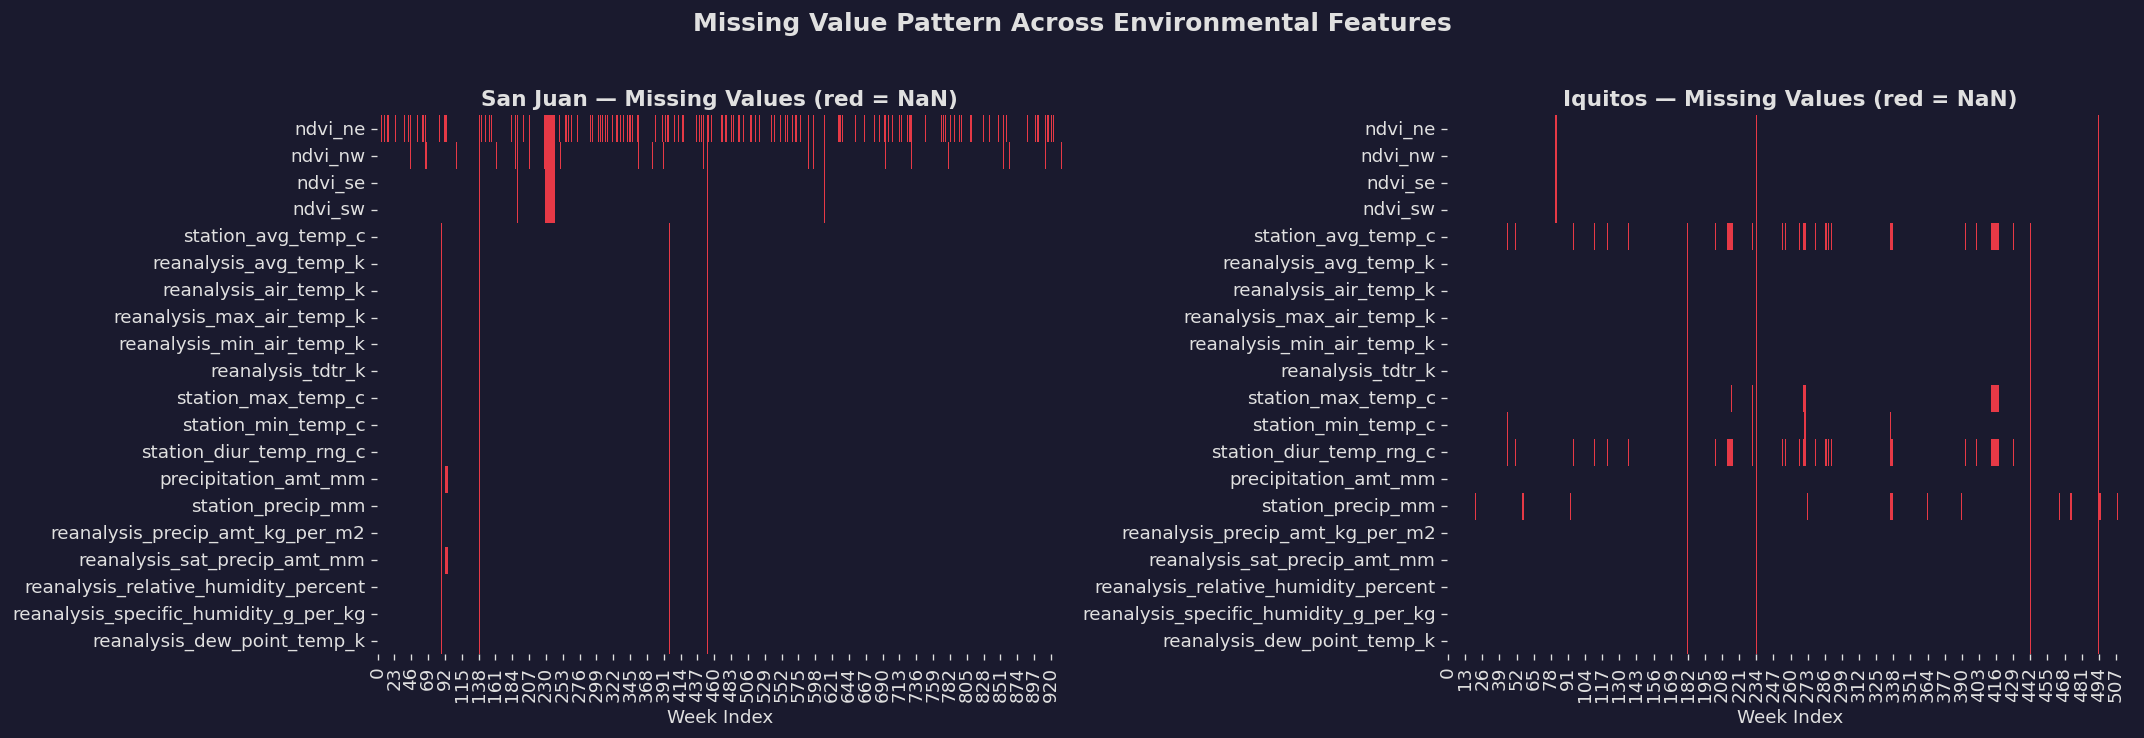

In [7]:
# Missing-value heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (dfc, name) in zip(axes, [(df_sj, 'sj'), (df_iq, 'iq')]):
    cols = [c for c in ENV_FEATURE_COLS if c in dfc.columns]
    sns.heatmap(dfc[cols].isnull().T, cbar=False, ax=ax,
                cmap=['#1A1A2E', '#E63946'], yticklabels=True)
    ax.set_title(f'{city_label(name)} — Missing Values (red = NaN)', fontsize=13)
    ax.set_xlabel('Week Index')

fig.suptitle('Missing Value Pattern Across Environmental Features', fontsize=15, y=1.02)
plt.tight_layout()
save_fig(fig, '01_missing_heatmap')
plt.show()

## 4 · Dengue Cases — Time Series

  ✅ Saved → figures\01_cases_timeseries.png


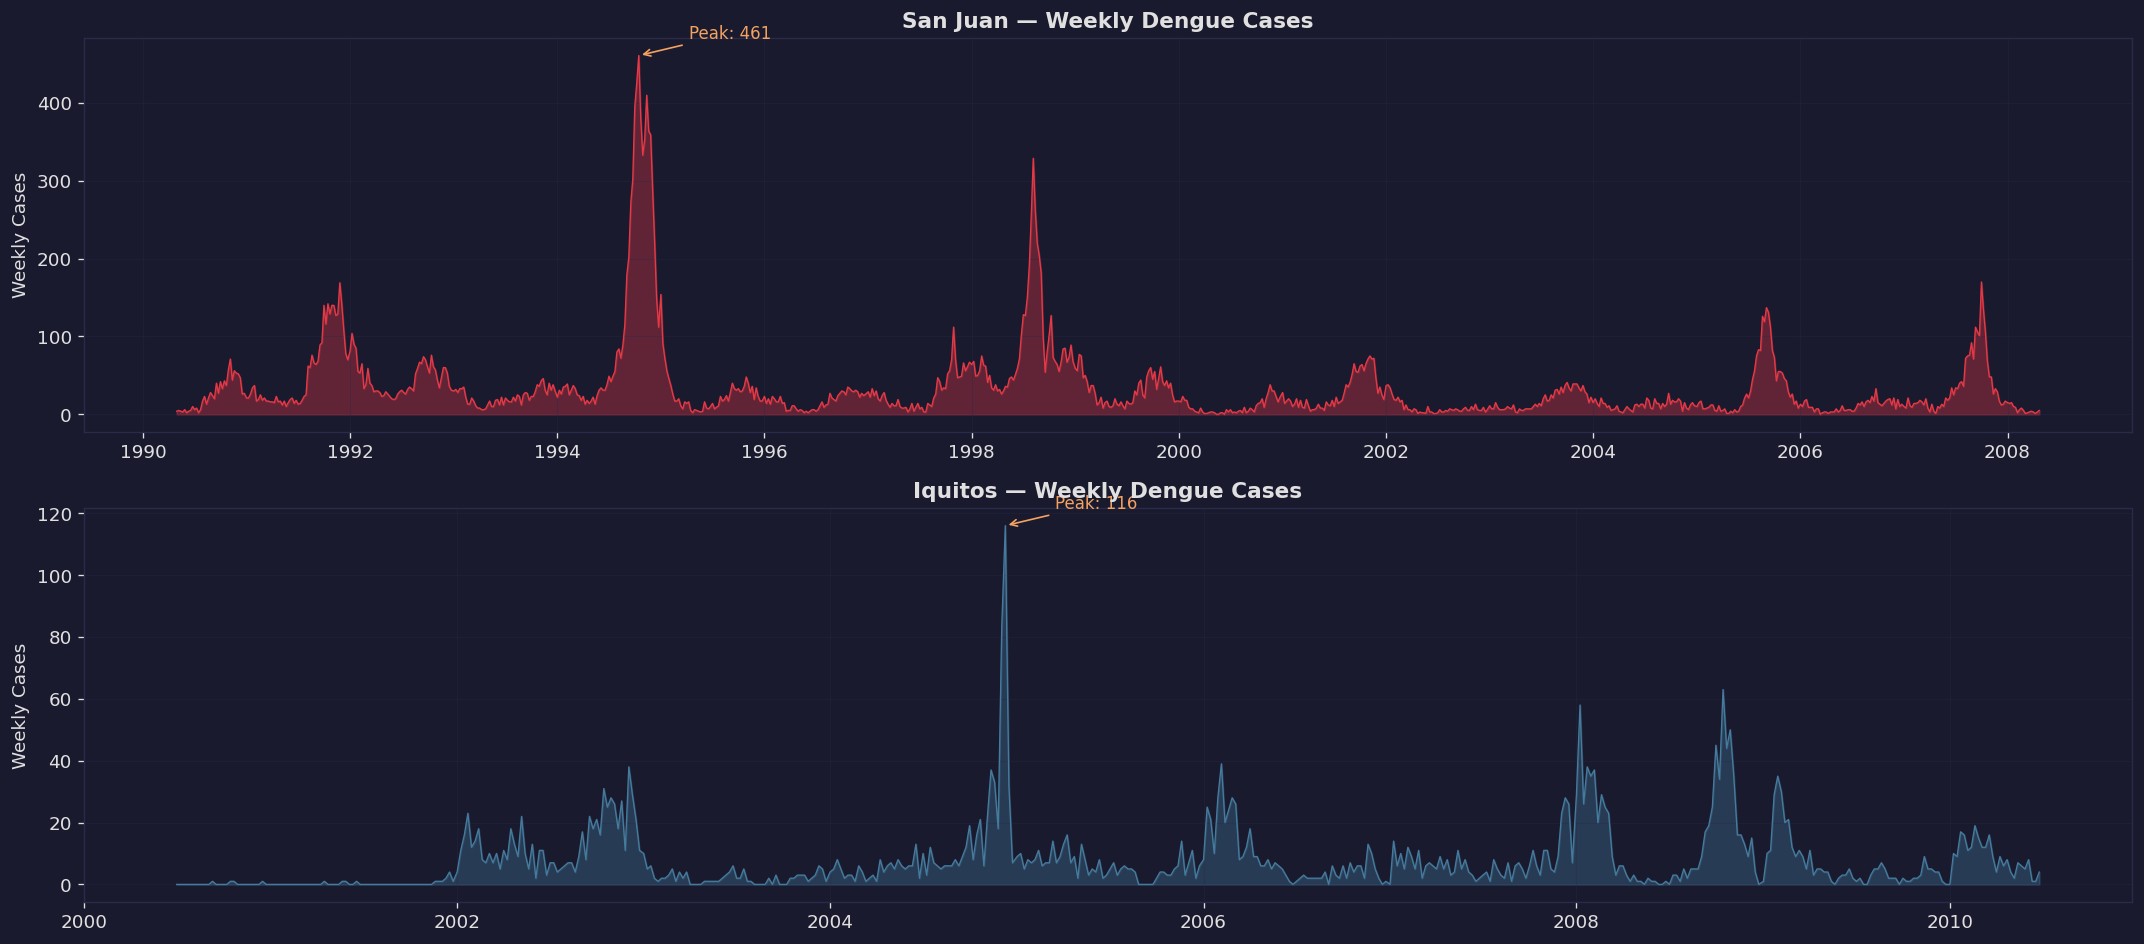

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=False)

for ax, (dfc, code) in zip(axes, [(df_sj, 'sj'), (df_iq, 'iq')]):
    ax.fill_between(dfc['week_start_date'], dfc['total_cases'],
                    alpha=0.35, color=city_color(code))
    ax.plot(dfc['week_start_date'], dfc['total_cases'],
            color=city_color(code), linewidth=0.8)
    ax.set_ylabel('Weekly Cases')
    ax.set_title(f'{city_label(code)} — Weekly Dengue Cases', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

    # Annotate peak
    peak_idx = dfc['total_cases'].idxmax()
    peak_date = dfc.loc[peak_idx, 'week_start_date']
    peak_val  = dfc.loc[peak_idx, 'total_cases']
    ax.annotate(f'Peak: {peak_val}', xy=(peak_date, peak_val),
                xytext=(30, 10), textcoords='offset points',
                fontsize=10, color=PALETTE['accent'],
                arrowprops=dict(arrowstyle='->', color=PALETTE['accent']))

plt.tight_layout()
save_fig(fig, '01_cases_timeseries')
plt.show()

## 5 · Seasonal Patterns

  ✅ Saved → figures\01_seasonal_pattern.png


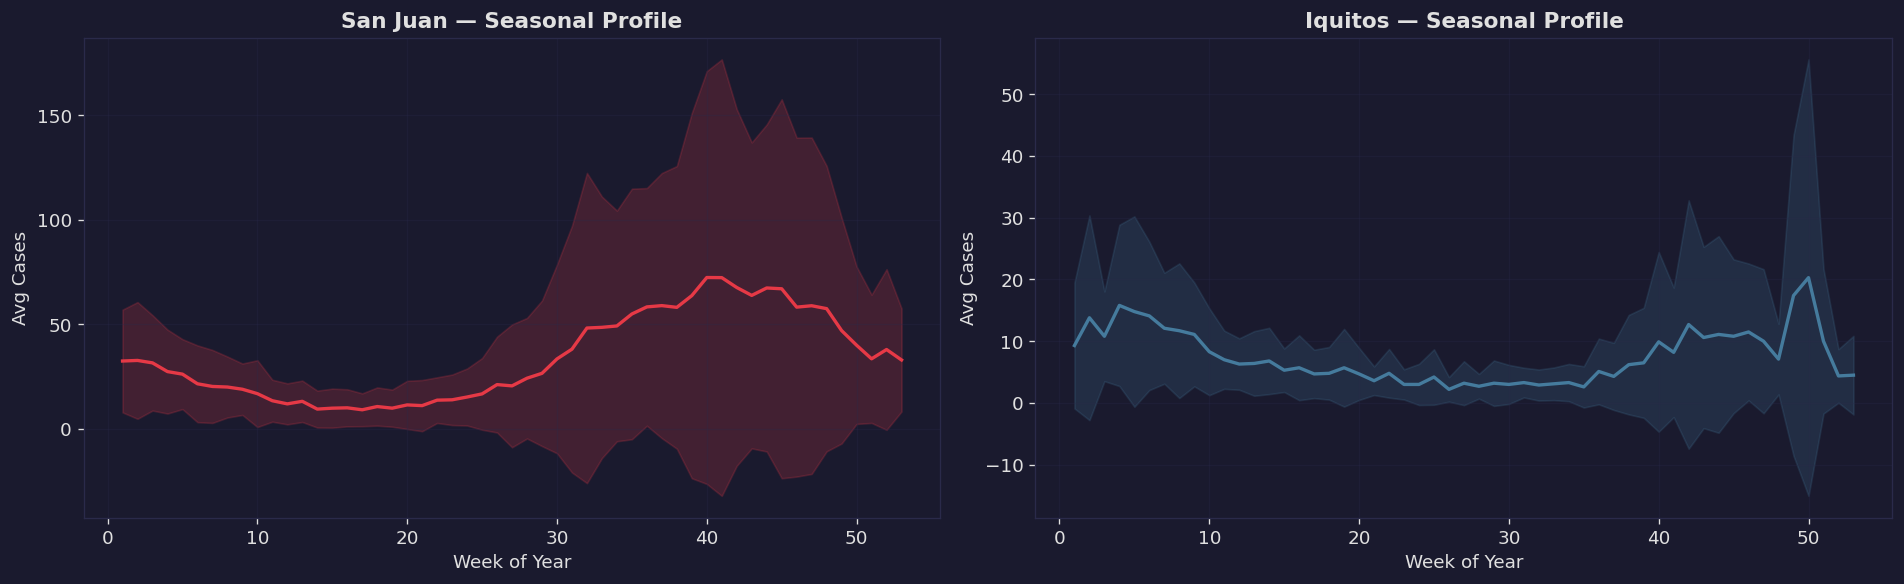

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (dfc, code) in zip(axes, [(df_sj, 'sj'), (df_iq, 'iq')]):
    seasonal = dfc.groupby('weekofyear')['total_cases'].agg(['mean','std']).reset_index()
    ax.fill_between(seasonal['weekofyear'],
                    seasonal['mean'] - seasonal['std'],
                    seasonal['mean'] + seasonal['std'],
                    alpha=0.2, color=city_color(code))
    ax.plot(seasonal['weekofyear'], seasonal['mean'],
            color=city_color(code), linewidth=2)
    ax.set_xlabel('Week of Year')
    ax.set_ylabel('Avg Cases')
    ax.set_title(f'{city_label(code)} — Seasonal Profile', fontsize=13)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '01_seasonal_pattern')
plt.show()

## 6 · Case Distribution

  ✅ Saved → figures\01_case_distribution.png


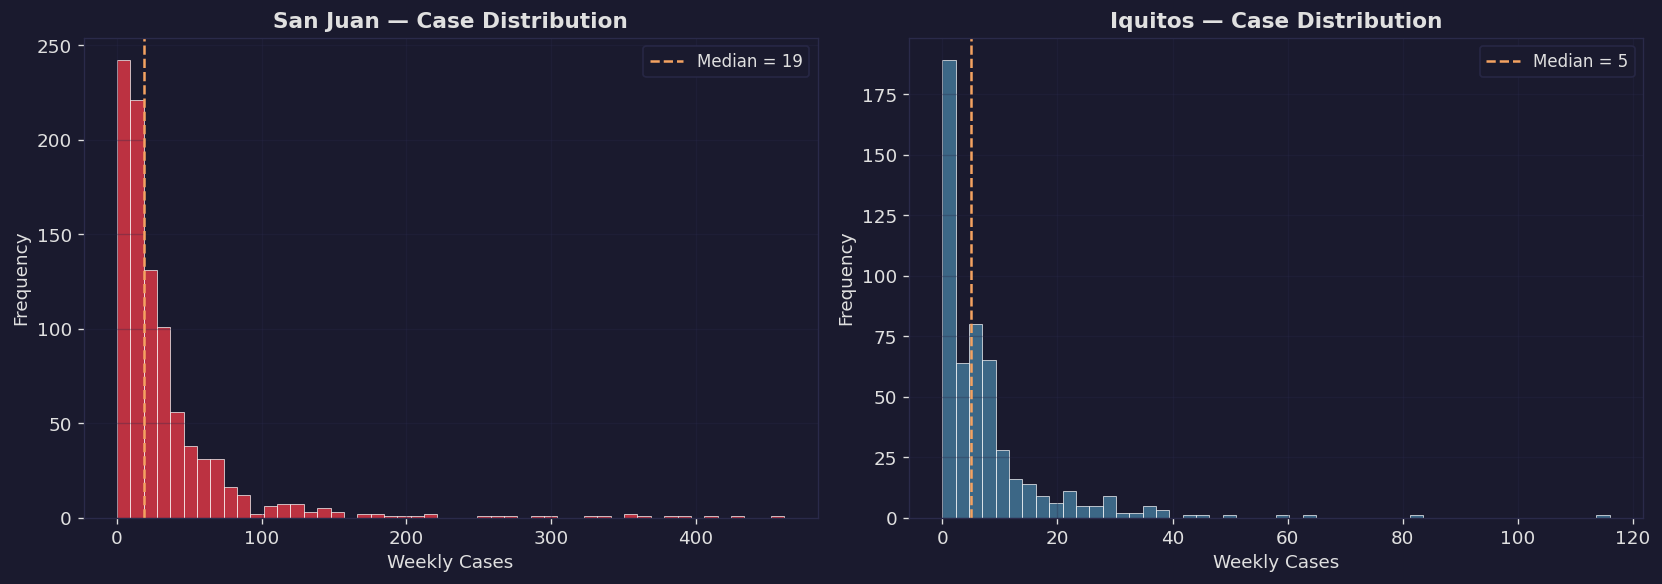

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (dfc, code) in zip(axes, [(df_sj, 'sj'), (df_iq, 'iq')]):
    ax.hist(dfc['total_cases'].dropna(), bins=50,
            color=city_color(code), alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(dfc['total_cases'].median(), color=PALETTE['accent'],
               linestyle='--', label=f'Median = {dfc["total_cases"].median():.0f}')
    ax.set_xlabel('Weekly Cases')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{city_label(code)} — Case Distribution', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '01_case_distribution')
plt.show()

## 7 · Environmental Feature Distributions

C:\Users\Mayank Gupta\AppData\Local\Temp\ipykernel_8008\2480116360.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_melt, x='Feature', y='Value', ax=ax,
C:\Users\Mayank Gupta\AppData\Local\Temp\ipykernel_8008\2480116360.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_melt, x='Feature', y='Value', ax=ax,
C:\Users\Mayank Gupta\AppData\Local\Temp\ipykernel_8008\2480116360.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_melt, x='Feature', y='Value', ax=ax,
C:\Users\Mayank Gupta\AppData\Local\Temp\ipyke

  ✅ Saved → figures\01_env_distributions_sj.png


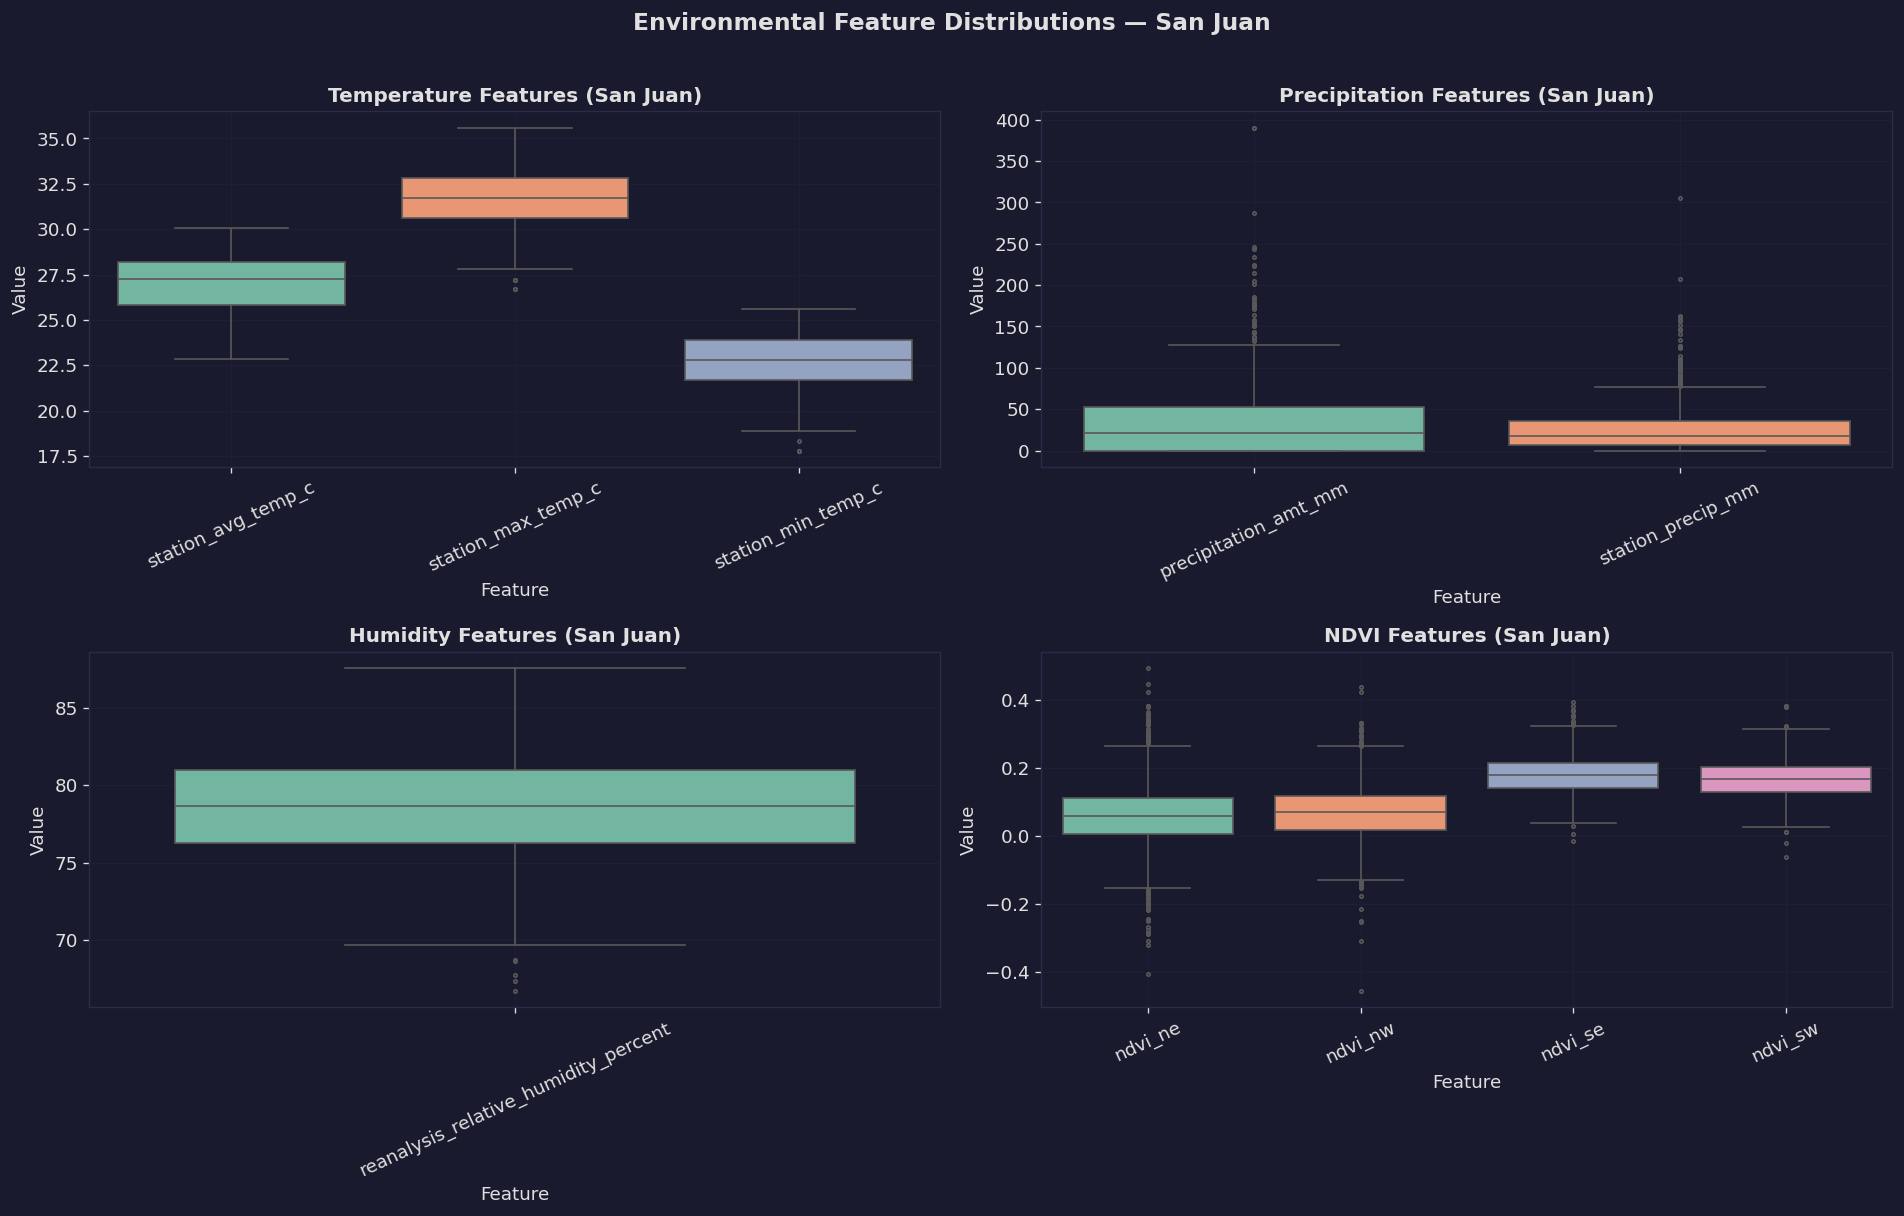

In [11]:
# Box-plots for the four main covariate groups (San Juan)
groups = {
    'Temperature': ['station_avg_temp_c', 'station_max_temp_c', 'station_min_temp_c'],
    'Precipitation': ['precipitation_amt_mm', 'station_precip_mm'],
    'Humidity': ['reanalysis_relative_humidity_percent'],
    'NDVI': NDVI_COLS,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (grp_name, cols) in zip(axes.flat, groups.items()):
    data_melt = df_sj[cols].melt(var_name='Feature', value_name='Value')
    sns.boxplot(data=data_melt, x='Feature', y='Value', ax=ax,
                palette='Set2', fliersize=2)
    ax.set_title(f'{grp_name} Features (San Juan)', fontsize=12)
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, alpha=0.3)

plt.suptitle('Environmental Feature Distributions — San Juan', fontsize=14, y=1.01)
plt.tight_layout()
save_fig(fig, '01_env_distributions_sj')
plt.show()

## 8 · Correlation Analysis

  ✅ Saved → figures\01_correlation_heatmap_sj.png


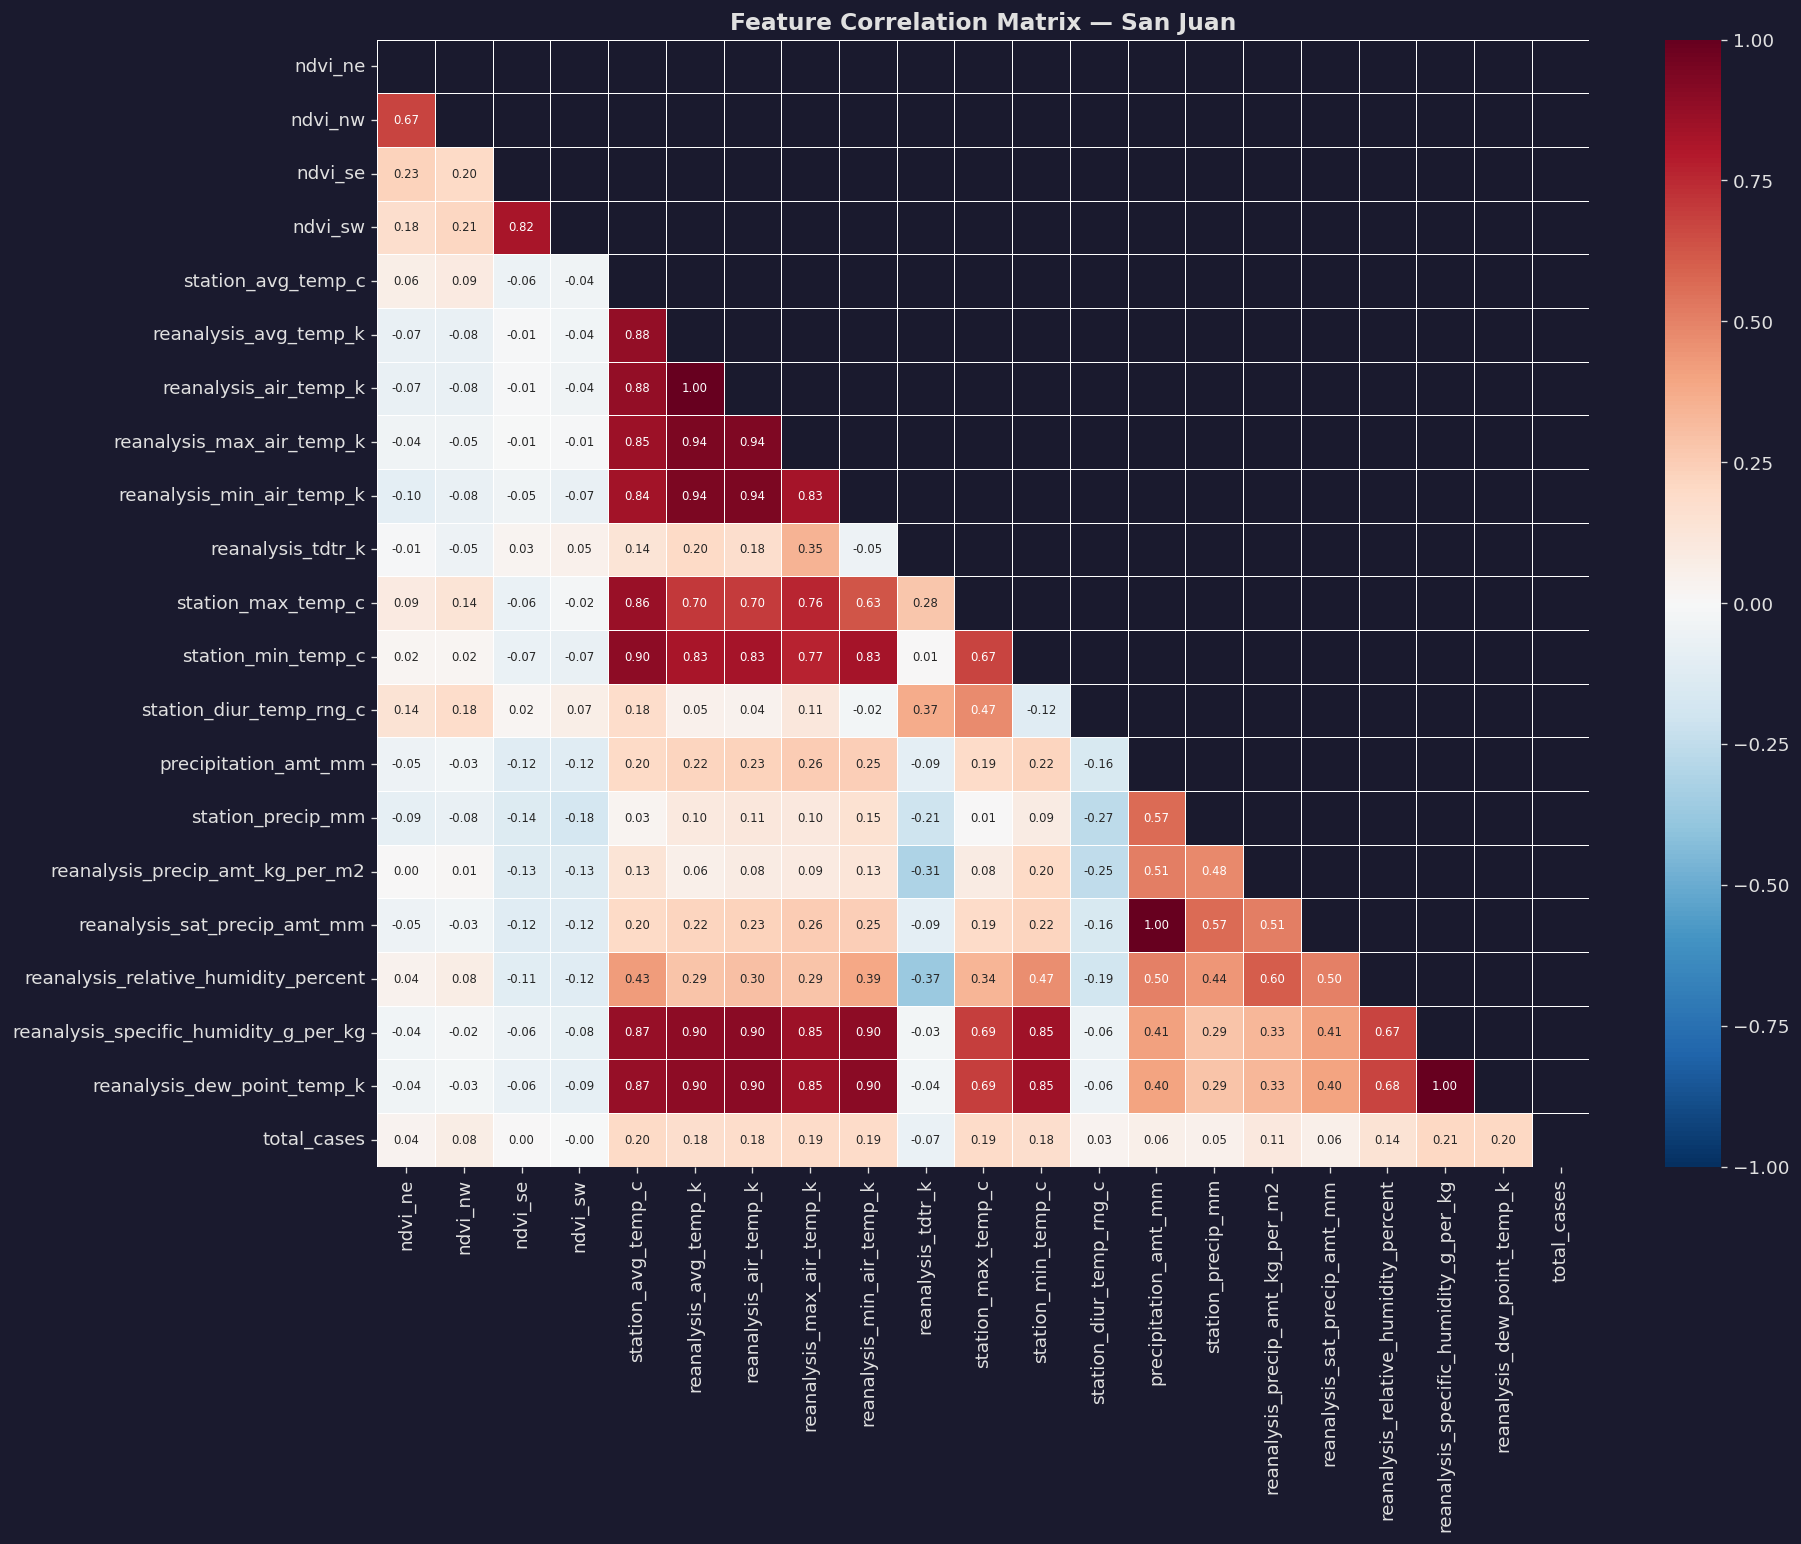

In [12]:
# Full correlation heatmap for San Juan
corr_cols = [c for c in ENV_FEATURE_COLS if c in df_sj.columns] + ['total_cases']
corr_matrix = df_sj[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Feature Correlation Matrix — San Juan', fontsize=14)
plt.tight_layout()
save_fig(fig, '01_correlation_heatmap_sj')
plt.show()

  ✅ Saved → figures\01_feature_case_correlation.png


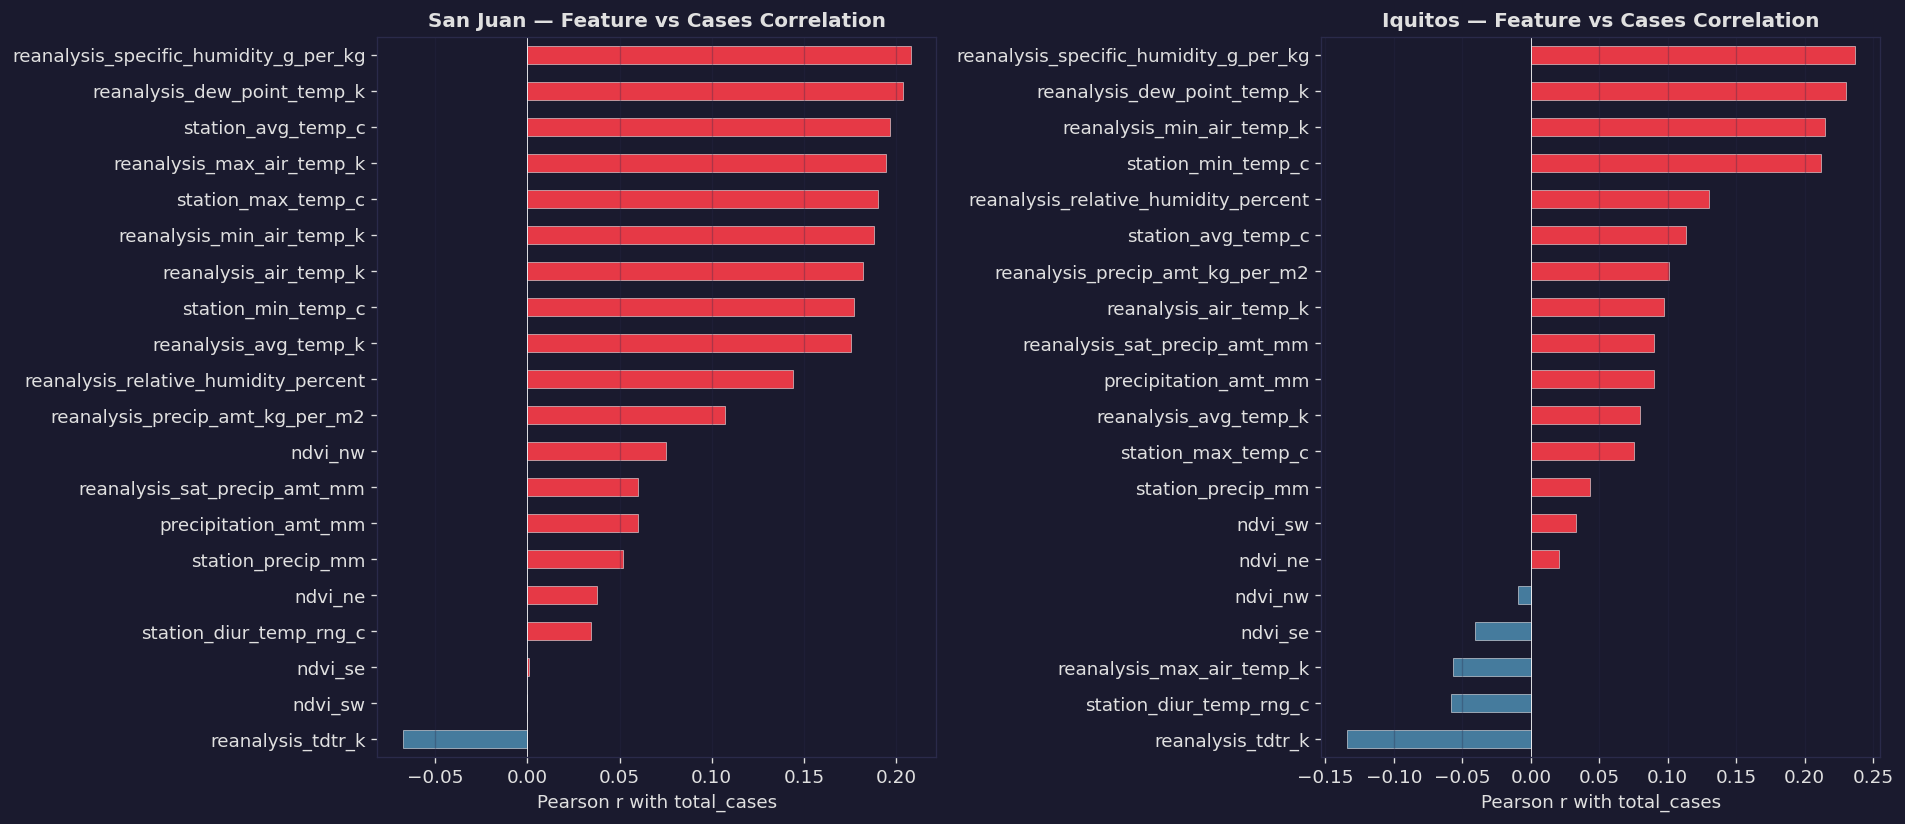

In [13]:
# Correlation with total_cases — bar chart for both cities
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (dfc, code) in zip(axes, [(df_sj, 'sj'), (df_iq, 'iq')]):
    env_cols = [c for c in ENV_FEATURE_COLS if c in dfc.columns]
    corrs = dfc[env_cols + ['total_cases']].corr()['total_cases'].drop('total_cases')
    corrs = corrs.sort_values()
    colors = [PALETTE['sj'] if v > 0 else PALETTE['iq'] for v in corrs.values]
    corrs.plot.barh(ax=ax, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Pearson r with total_cases')
    ax.set_title(f'{city_label(code)} — Feature vs Cases Correlation', fontsize=12)
    ax.axvline(0, color='white', linewidth=0.5)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, '01_feature_case_correlation')
plt.show()

## 9 · Key Features vs Cases Over Time

  ✅ Saved → figures\01_cases_vs_environment_sj.png


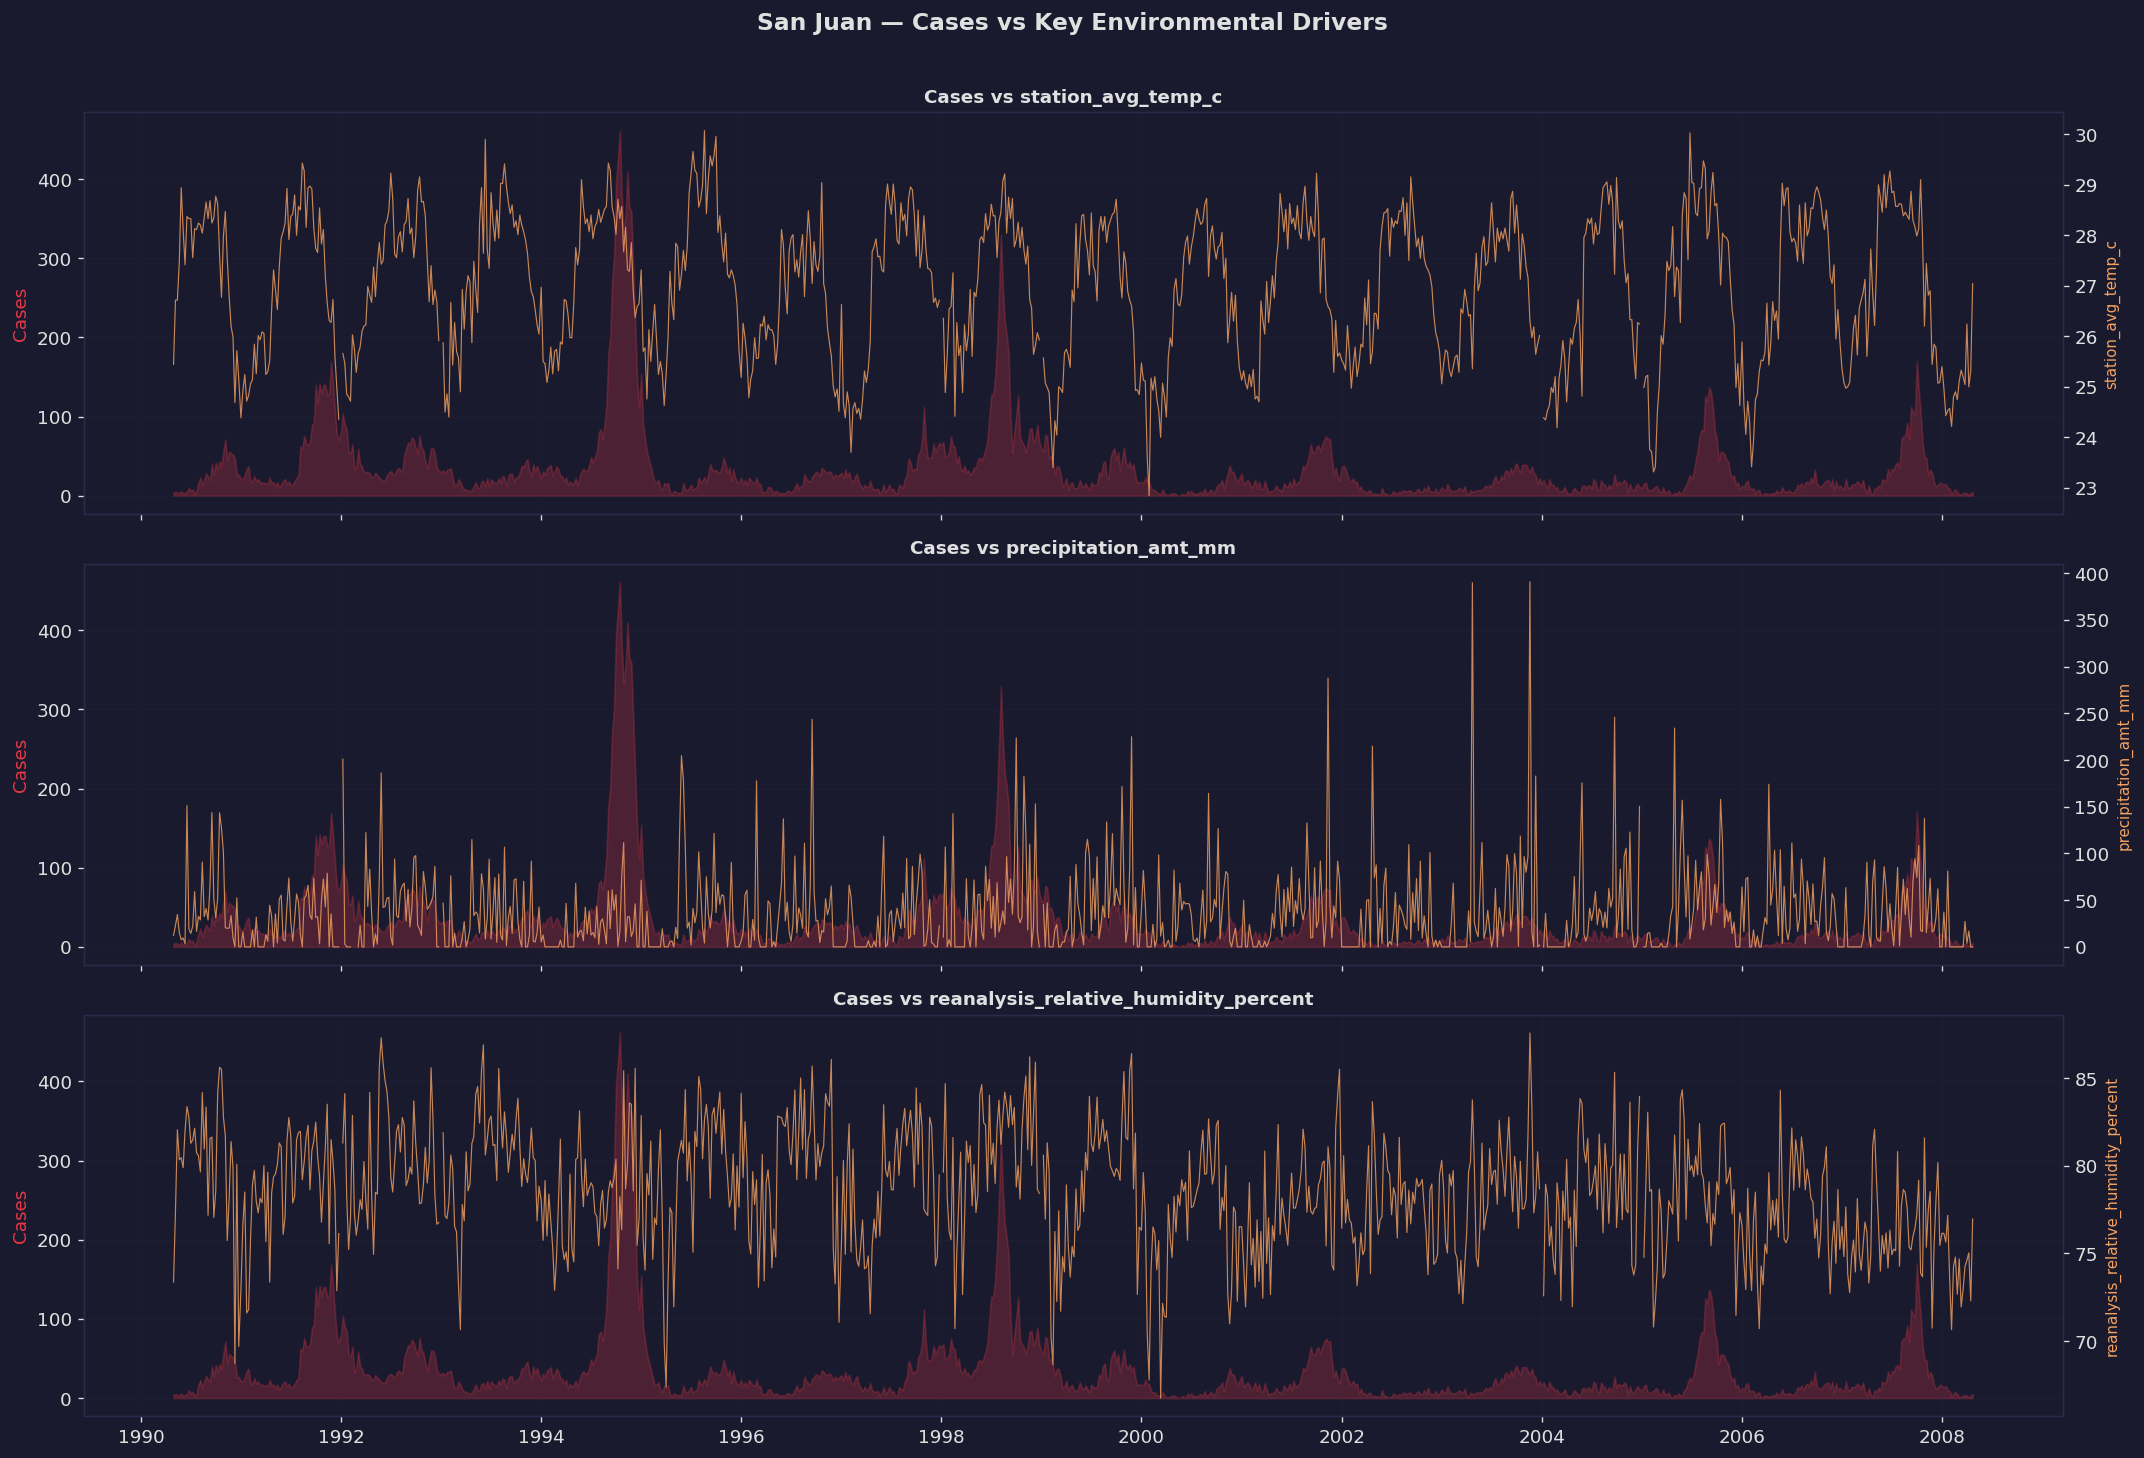

In [14]:
# Overlay key environmental features with cases for San Juan
key_features = ['station_avg_temp_c', 'precipitation_amt_mm',
                'reanalysis_relative_humidity_percent']

fig, axes = plt.subplots(len(key_features), 1, figsize=(18, 12), sharex=True)

for ax, feat in zip(axes, key_features):
    ax2 = ax.twinx()
    ax.fill_between(df_sj['week_start_date'], df_sj['total_cases'],
                    alpha=0.25, color=PALETTE['sj'])
    ax.set_ylabel('Cases', color=PALETTE['sj'])

    ax2.plot(df_sj['week_start_date'], df_sj[feat],
             color=PALETTE['accent'], linewidth=0.7, alpha=0.8)
    ax2.set_ylabel(feat, color=PALETTE['accent'], fontsize=9)

    ax.set_title(f'Cases vs {feat}', fontsize=11)
    ax.grid(True, alpha=0.2)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
fig.suptitle('San Juan — Cases vs Key Environmental Drivers', fontsize=14, y=1.01)
plt.tight_layout()
save_fig(fig, '01_cases_vs_environment_sj')
plt.show()

## 10 · NDVI Analysis

  ✅ Saved → figures\01_ndvi_timeseries.png


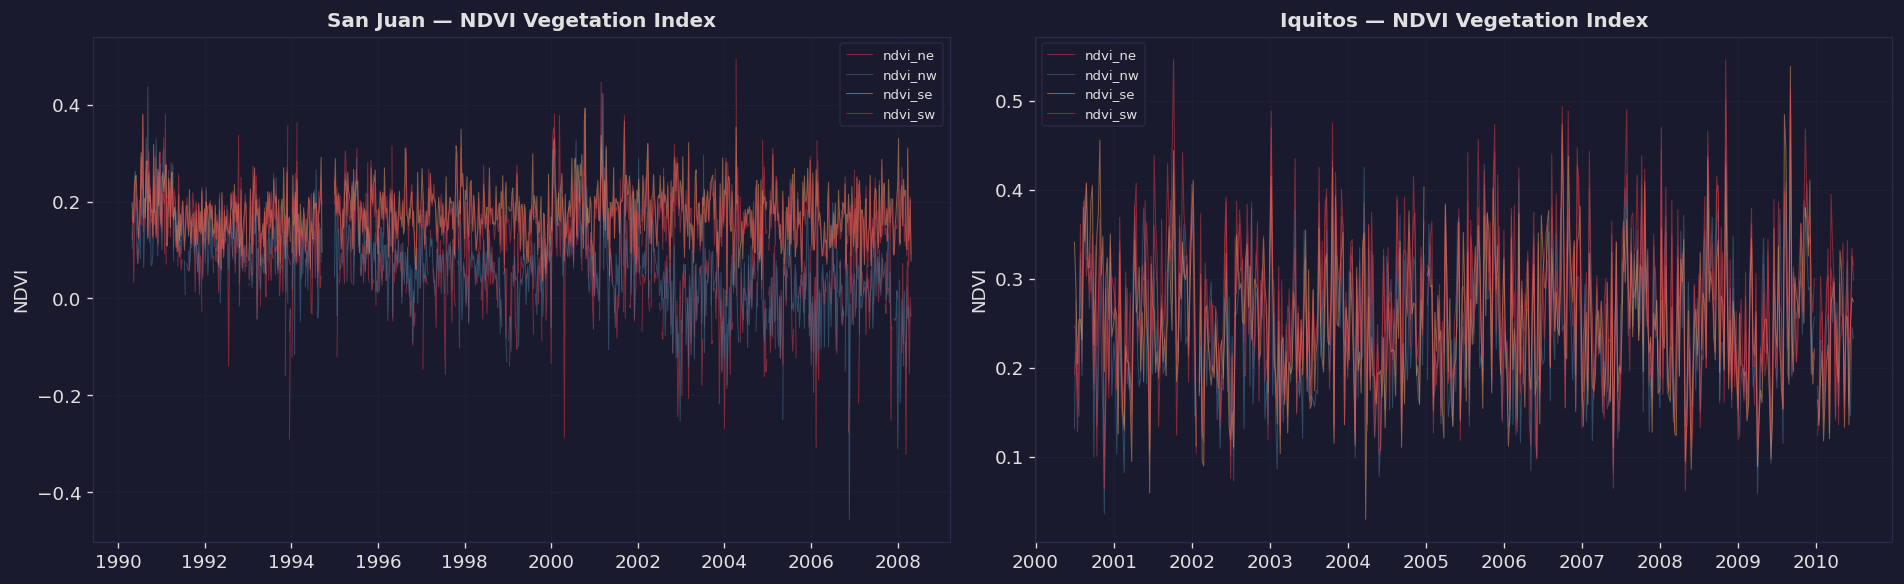

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (dfc, code) in zip(axes, [(df_sj, 'sj'), (df_iq, 'iq')]):
    for col in NDVI_COLS:
        ax.plot(dfc['week_start_date'], dfc[col], alpha=0.5, linewidth=0.6, label=col)
    ax.set_title(f'{city_label(code)} — NDVI Vegetation Index', fontsize=12)
    ax.set_ylabel('NDVI')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '01_ndvi_timeseries')
plt.show()

## 11 · Major Epidemic Events

In [16]:
# Identify top epidemic peaks in San Juan
yearly_sj = df_sj.groupby('year')['total_cases'].sum().sort_values(ascending=False)
print('San Juan — Top 5 Epidemic Years:')
print(yearly_sj.head())

print('\n')
yearly_iq = df_iq.groupby('year')['total_cases'].sum().sort_values(ascending=False)
print('Iquitos — Top 5 Epidemic Years:')
print(yearly_iq.head())

San Juan — Top 5 Epidemic Years:
year
1994    6533
1998    4595
1991    2801
1992    2371
2007    1969
Name: total_cases, dtype: int64


Iquitos — Top 5 Epidemic Years:
year
2008    801
2002    704
2004    638
2006    436
2007    365
Name: total_cases, dtype: int64


  ✅ Saved → figures\01_annual_cases.png


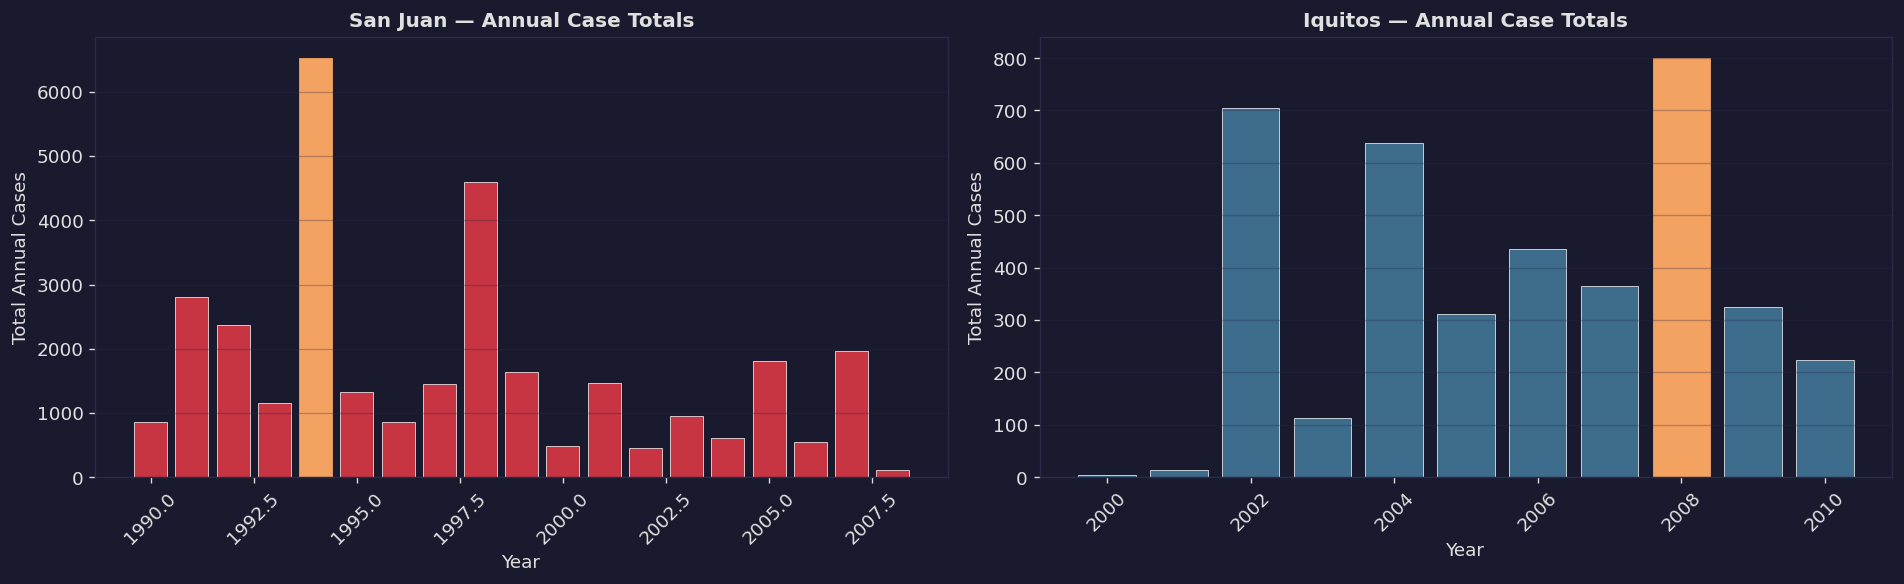

In [17]:
# Year-wise case totals bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (yearly, code) in zip(axes, [(yearly_sj, 'sj'), (yearly_iq, 'iq')]):
    yearly_sorted = yearly.sort_index()
    bars = ax.bar(yearly_sorted.index, yearly_sorted.values,
                  color=city_color(code), alpha=0.85, edgecolor='white', linewidth=0.5)
    # Highlight top year
    top_year = yearly_sorted.idxmax()
    top_idx = list(yearly_sorted.index).index(top_year)
    bars[top_idx].set_color(PALETTE['accent'])
    bars[top_idx].set_alpha(1.0)

    ax.set_xlabel('Year')
    ax.set_ylabel('Total Annual Cases')
    ax.set_title(f'{city_label(code)} — Annual Case Totals', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig(fig, '01_annual_cases')
plt.show()

## 12 · Scatter: Temperature & Precipitation vs Cases

  ✅ Saved → figures\01_scatter_env_vs_cases.png


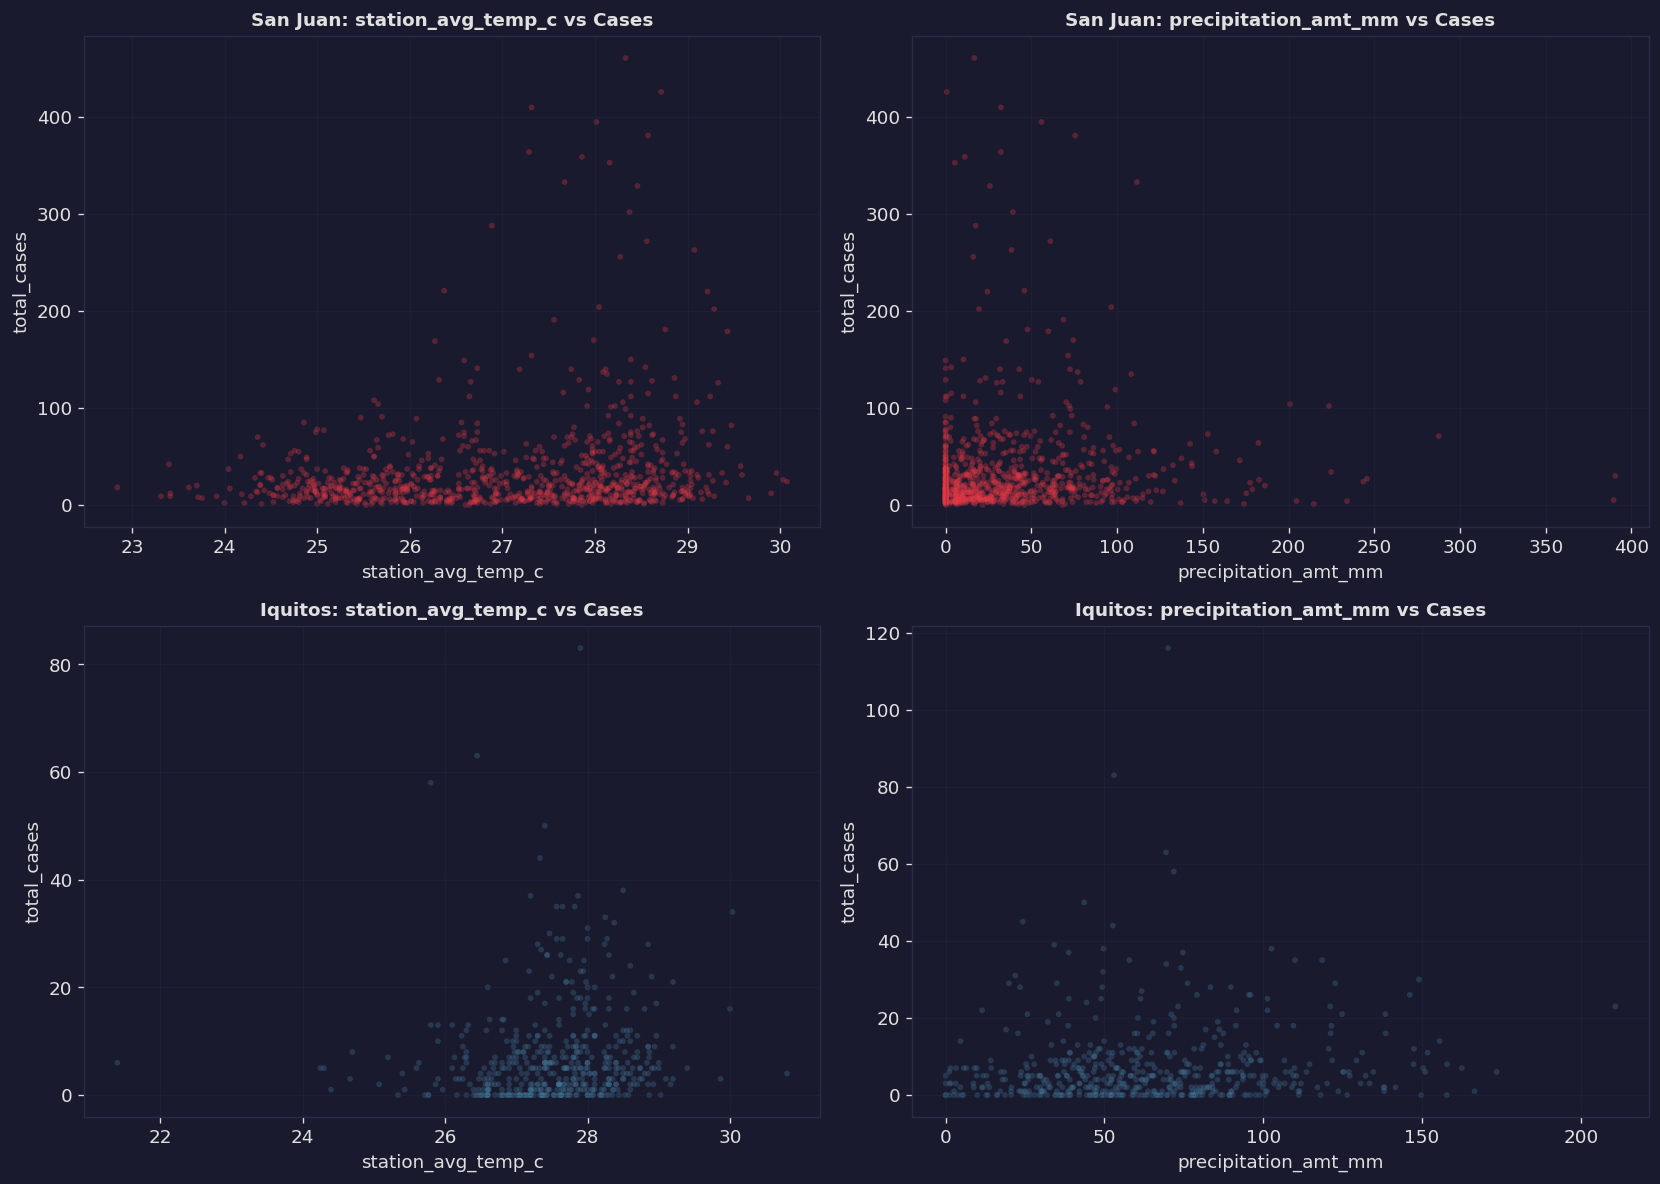

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_feats = ['station_avg_temp_c', 'precipitation_amt_mm']
for row, (dfc, code) in enumerate([(df_sj, 'sj'), (df_iq, 'iq')]):
    for col_idx, feat in enumerate(scatter_feats):
        ax = axes[row, col_idx]
        ax.scatter(dfc[feat], dfc['total_cases'],
                   alpha=0.3, s=12, color=city_color(code), edgecolors='none')
        ax.set_xlabel(feat)
        ax.set_ylabel('total_cases')
        ax.set_title(f'{city_label(code)}: {feat} vs Cases', fontsize=11)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '01_scatter_env_vs_cases')
plt.show()

## 13 · Multicollinearity Check

In [19]:
# Highly correlated feature pairs (|r| > 0.85)
env_cols = [c for c in ENV_FEATURE_COLS if c in df_sj.columns]
corr = df_sj[env_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and val > 0.85:
            high_corr.append((idx, col, round(val, 3)))

high_corr_df = pd.DataFrame(high_corr, columns=['Feature_1', 'Feature_2', 'Correlation'])
high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)
print(f'Found {len(high_corr_df)} highly correlated pairs (|r| > 0.85):\n')
display(high_corr_df)

Found 22 highly correlated pairs (|r| > 0.85):



,Feature_1,Feature_2,Correlation
10,precipitation_amt_mm,reanalysis_sat_precip_amt_mm,1.000
21,reanalysis_specific_humidity_g_per_kg,reanalysis_dew_point_temp_k,0.999
2,reanalysis_avg_temp_k,reanalysis_air_temp_k,0.997
7,reanalysis_air_temp_k,reanalysis_min_air_temp_k,0.942
6,reanalysis_avg_temp_k,reanalysis_min_air_temp_k,0.939
4,reanalysis_avg_temp_k,reanalysis_max_air_temp_k,0.939
5,reanalysis_air_temp_k,reanalysis_max_air_temp_k,0.935
13,reanalysis_air_temp_k,reanalysis_specific_humidity_g_per_kg,0.905
18,reanalysis_air_temp_k,reanalysis_dew_point_temp_k,0.903
19,reanalysis_min_air_temp_k,reanalysis_dew_point_temp_k,0.899


## 📝 EDA Key Findings

| Finding | Detail |
|---|---|
| **Data size** | San Juan: ~936 weeks (1990–2008), Iquitos: ~520 weeks (2000–2010) |
| **Missing values** | < 5% for most features; NDVI has highest missingness |
| **Seasonality** | Clear annual cycle — cases peak in late summer/fall (weeks 35–50) |
| **Epidemics** | Major SJ outbreaks: 1994 (461 peak), 1998 (329 peak) |
| **Multicollinearity** | Temperature features highly correlated with each other |
| **Key correlations** | Temperature & humidity features show moderate positive correlation with cases |
| **Implication for SINDy** | Need to aggregate correlated features → 4 covariates (T, P, H, V) or use PCA |

---
**Next →** Notebook 02: Preprocessing (missing value imputation, feature aggregation, lag creation)